<a href="https://colab.research.google.com/github/keshav123333/langgraph/blob/main/lecture11_persistance/lecture11_persistance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain-huggingFace langgraph


In [32]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

llm=HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="conversational",


    temperature=0.7
)


# yaha maine kayde se like optimizer ke liye and generate tweet ke liye and evealuation teeno ke iye alag llm use karna chaiye jo uss task m excel ho
# like research ki kaunsa llm  vocab achi usse tweet generate kaunsa ache se feedback leta kaunsa sa llm evealuation achi karta aise

llm=ChatHuggingFace(llm=llm)

#Persistence

sun jaise main dikkat kya hoti hai jab humara worflow end hota hai toh state jo hota empty ho jata hai so vo toh ud gaya toh ab kya kare ishe probelm ko solve ye karta hau






jaise pehle maine ek chatbot banaya isse pehle wala lecture dekh usme maine lagaya tab jaake vo purani hceeze yaad kar paya as ek baar while loop ho jaane ke baad vo exit ho jata hai and state empty

and persistance fault tolerance deta like har node ke baad checkpoints hote and state ko save karta rehta

# iska video dekh if tu use kar raha hai isse no other choice sachi

# workflow

In [33]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [34]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [35]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [36]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)
checkpointer = InMemorySaver() # ram mein save karta hai value

workflow = graph.compile(checkpointer=checkpointer)

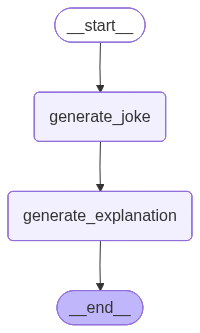

In [39]:
workflow

In [37]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the doctor? \n\nIt was feeling a little crusty.',
 'explanation': 'The joke "Why did the pizza go to the doctor? It was feeling a little crusty" is a play on words. \n\nThe phrase "feeling a little crusty" has a double meaning here. In human language, "crusty" is often used to describe someone who is grumpy, irritable, or having a bad temper. However, in the context of a pizza, "crusty" refers to the outer layer of the bread that is typically crispy and golden brown.\n\nThe joke relies on this wordplay to create humor. The listener is initially expecting the punchline to be a reason related to human emotions, but instead, it\'s a clever reference to the physical aspect of a pizza. This unexpected twist creates the comedic effect, making the joke amusing and clever.'}

In [38]:
workflow.get_state(config1)  #ye final state dega

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? \n\nIt was feeling a little crusty.', 'explanation': 'The joke "Why did the pizza go to the doctor? It was feeling a little crusty" is a play on words. \n\nThe phrase "feeling a little crusty" has a double meaning here. In human language, "crusty" is often used to describe someone who is grumpy, irritable, or having a bad temper. However, in the context of a pizza, "crusty" refers to the outer layer of the bread that is typically crispy and golden brown.\n\nThe joke relies on this wordplay to create humor. The listener is initially expecting the punchline to be a reason related to human emotions, but instead, it\'s a clever reference to the physical aspect of a pizza. This unexpected twist creates the comedic effect, making the joke amusing and clever.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c66b-ac25-6985-8002-0548ed2efef8'}}, metadata={'source

In [41]:
# if history matlab har node ke baad ka out toh ye lokh

list(workflow.get_state_history(config1))

# ye upar jo aaya ye final niche dekh usme  StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',)
# so ye bata raha ki srur mein start node se pehel kya tha and vo start ke baad ganerate node m jaa raha hai

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? \n\nIt was feeling a little crusty.', 'explanation': 'The joke "Why did the pizza go to the doctor? It was feeling a little crusty" is a play on words. \n\nThe phrase "feeling a little crusty" has a double meaning here. In human language, "crusty" is often used to describe someone who is grumpy, irritable, or having a bad temper. However, in the context of a pizza, "crusty" refers to the outer layer of the bread that is typically crispy and golden brown.\n\nThe joke relies on this wordplay to create humor. The listener is initially expecting the punchline to be a reason related to human emotions, but instead, it\'s a clever reference to the physical aspect of a pizza. This unexpected twist creates the comedic effect, making the joke amusing and clever.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c66b-ac25-6985-8002-0548ed2efef8'}}, metadata={'sourc

In [42]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti go to therapy? \n\nBecause it was feeling a little "twisted."',
 'explanation': 'The joke "Why did the spaghetti go to therapy? Because it was feeling a little \'twisted\'" is a play on words. \n\nIn this joke, the phrase "feeling a little twisted" has a double meaning. \n\n1. The word "twisted" can describe a piece of spaghetti that is tangled or knotted, which is a literal description of the pasta\'s form.\n2. The phrase "feeling a little twisted" is also an idiom that means feeling anxious, upset, or emotionally unstable. \n\nThe joke relies on this wordplay to create a pun, where the literal meaning of "twisted" (tangled spaghetti) is used to make a humorous connection to the idiomatic meaning (feeling anxious). This clever use of language creates a lighthearted and amusing effect, making the joke enjoyable and relatable.'}

In [43]:
# same hi workflow ki alag alag state bana sakta
print(workflow.get_state(config2))
print(">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>")
print(list(workflow.get_state_history(config1)))
# config 1 ka yaha dikhaya nikal ke ki vo bhi save hai bas ram main save hai

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? \n\nIt was feeling a little crusty.', 'explanation': 'The joke "Why did the pizza go to the doctor? It was feeling a little crusty" is a play on words. \n\nThe phrase "feeling a little crusty" has a double meaning here. In human language, "crusty" is often used to describe someone who is grumpy, irritable, or having a bad temper. However, in the context of a pizza, "crusty" refers to the outer layer of the bread that is typically crispy and golden brown.\n\nThe joke relies on this wordplay to create humor. The listener is initially expecting the punchline to be a reason related to human emotions, but instead, it\'s a clever reference to the physical aspect of a pizza. This unexpected twist creates the comedic effect, making the joke amusing and clever.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c66b-ac25-6985-8002-0548ed2efef8'}}, metadata={'source

# fault tolerance kaise vo dekh lecture 11 ka 38min se dekh video  usme bata node bhejte hai  dekh le achi cheez hai

In [47]:
list(workflow.get_state_history(config=config1)) # yaha output se statesnapshot har ek ka khudka checkpoint id usse utha ek ki
#maan tujhe generatejoke wale step mein kuch change karna and uss workflow ko vapis pura chalna toh ye possible isse hi hai

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? \n\nIt was feeling a little crusty.', 'explanation': 'The joke "Why did the pizza go to the doctor? It was feeling a little crusty" is a play on words. \n\nThe phrase "feeling a little crusty" has a double meaning here. In human language, "crusty" is often used to describe someone who is grumpy, irritable, or having a bad temper. However, in the context of a pizza, "crusty" refers to the outer layer of the bread that is typically crispy and golden brown.\n\nThe joke relies on this wordplay to create humor. The listener is initially expecting the punchline to be a reason related to human emotions, but instead, it\'s a clever reference to the physical aspect of a pizza. This unexpected twist creates the comedic effect, making the joke amusing and clever.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c66b-ac25-6985-8002-0548ed2efef8'}}, metadata={'sourc

In [48]:
workflow.get_state({"configurable":{"thread_id":"1","checkpoint_id":"1f12c66b-a5de-6c18-8000-a7e058109bb6"}}) #yaha pe chekpoint id se maine vo wali state nikal li jab genrate topic tha

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f12c66b-a5de-6c18-8000-a7e058109bb6'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-03-30T18:31:55.019961+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c66b-a5d8-6c65-bfff-1f761a2fa340'}}, tasks=(PregelTask(id='39964750-dfc4-194b-ce1b-27215639a10a', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza go to the doctor? \n\nIt was feeling a little crusty.'}),), interrupts=())

In [49]:
#yaha pe dekh maine kya kiya none isliye as chali hui ko bich se chala rahe and state thodi behjni vo pele wala state hi bhj diya toh dekh maine iss check point se sate vapic run karwa di
workflow.invoke(None,{"configurable":{"thread_id":"1","checkpoint_id":"1f12c66b-a5de-6c18-8000-a7e058109bb6"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the doctor? \n\nBecause it was feeling a little crusty.',
 'explanation': 'This joke relies on a play on words. The phrase "feeling a little crusty" has a double meaning here. In the context of human emotions, "crusty" can imply being irritable or having a bad temper. However, in the context of food, a pizza crust is a literal part of the pizza. \n\nThe joke works by taking a common phrase that typically describes a person\'s emotional state and applying it to a pizza, where the "crusty" part is a physical component. This unexpected twist creates the humor. The punchline is a clever play on words, making it a lighthearted and amusing joke.'}

In [50]:
# so yaha pe jab dekhega na toh jaise pehle state mein explanation ke baad ki state ab upar maine
# fir se run toh vo state bhi isme save hoti jayegi like isko samjhna mushkil hai bas
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? \n\nBecause it was feeling a little crusty.', 'explanation': 'This joke relies on a play on words. The phrase "feeling a little crusty" has a double meaning here. In the context of human emotions, "crusty" can imply being irritable or having a bad temper. However, in the context of food, a pizza crust is a literal part of the pizza. \n\nThe joke works by taking a common phrase that typically describes a person\'s emotional state and applying it to a pizza, where the "crusty" part is a physical component. This unexpected twist creates the humor. The punchline is a clever play on words, making it a lighthearted and amusing joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c68d-006d-6fae-8002-6e3d651e15d1'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-03-30T18:46:50.352809+00:00', parent_config={'configurable': {'thread_id

In [53]:
#maine fir se uss state pe gaya abki baar vo chalunga but uss state pe kuch value chege pehle pizza tha usse samosa
workflow.update_state({"configurable":{"thread_id":"1","checkpoint_id":"1f12c66b-a5de-6c18-8000-a7e058109bb6","checkpoint_ns": ""}},{"topic":"samosa"})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f12c69a-4723-6937-8001-3e885c2d44b9'}}

In [54]:
list(workflow.get_state_history(config1)) # so maine ek nayi bracnch bana di dekh but ye bramch excute ni hui
# sun meri baat main cheez ye hai ki tu dekhega video tab hi samjh ab maine iss samosa wale ki checkpoint id ye jo out m sabse upar h

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c69a-4723-6937-8001-3e885c2d44b9'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-03-30T18:52:46.733309+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c66b-a5de-6c18-8000-a7e058109bb6'}}, tasks=(PregelTask(id='c1da4e66-2910-b600-55ef-d4cfd8464750', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? \n\nBecause it was feeling a little crusty.', 'explanation': 'This joke relies on a play on words. The phrase "feeling a little crusty" has a double meaning here. In the context of human emotions, "crusty" can imply being irritable or having a bad temper. However, in the context of food, a piz

In [56]:
# so yaha maine kya kiya mujhe node ke bich se kuch value ko change karke check karna ki sirf vo chencge bich se toh aage ke node mein kaise output change
# so ye use maine upar ek branck banayi and usske checkpoint id banayi yaha maine uss checkpoint ko run karwaya ab
workflow.invoke(None,{"configurable":{"thread_id":"1","checkpoint_id":"1f12c69a-4723-6937-8001-3e885c2d44b9"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling crumby on the outside and wrapped up in its emotions on the inside.',
 'explanation': 'This joke is a play on words, using the double meaning of "crumby" and "wrapped up" to create a pun.\n\n"Crummy" or "crumby" is an adjective that means feeling unwell, unhappy, or in a bad mood. However, in the context of a samosa, "crumby" can also refer to the crispy, crunchy texture of the pastry crust, which can become crumbly or fall apart.\n\nThe phrase "wrapped up in its emotions" is a common idiom that means being preoccupied or overwhelmed by one\'s feelings. However, in the context of a samosa, "wrapped" also refers to the fact that a samosa is a pastry that is wrapped around a filling.\n\nThe joke relies on this double meaning to create a pun, where the samosa\'s "crumby" exterior is a play on words for its emotional state, and its being "wrapped up" in its emotions is a literal reference to its pastr

In [57]:
# ab vo explanation wali cheez bhi add ho gi hogi state mein persistance mein yaha niche do do baar ek hi cheez ad ho gi hogi as maine ek cell ko do baar run kar diya hai
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling crumby on the outside and wrapped up in its emotions on the inside.', 'explanation': 'This joke is a play on words, using the double meaning of "crumby" and "wrapped up" to create a pun.\n\n"Crummy" or "crumby" is an adjective that means feeling unwell, unhappy, or in a bad mood. However, in the context of a samosa, "crumby" can also refer to the crispy, crunchy texture of the pastry crust, which can become crumbly or fall apart.\n\nThe phrase "wrapped up in its emotions" is a common idiom that means being preoccupied or overwhelmed by one\'s feelings. However, in the context of a samosa, "wrapped" also refers to the fact that a samosa is a pastry that is wrapped around a filling.\n\nThe joke relies on this double meaning to create a pun, where the samosa\'s "crumby" exterior is a play on words for its emotional state, and its being "wrapped up" in its emotions is a literal re

#Fault tolerance

ye video dekh le but stil

In [58]:

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time


In [64]:
 #1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(10)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [65]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)


In [67]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [68]:

# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed

✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done'}
